## step 1: import relevant libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib

pd.set_option("display.max_columns", None)


## step 2: loading thet datase

In [4]:
import pandas as pd

customer_data = pd.read_csv(
    r"C:\Users\USER\OneDrive\Desktop\Telco-Customer_Churn\data\WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

In [5]:
customer_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## step 3: pre-cleaning EDA

In [6]:
def basic_ckecks(data):
    print(data.shape)
    print("duplicates",data.duplicated().sum())
    print(data.columns)
    print(data.dtypes)
    print(data.isnull().sum())
    print(display(data.describe().T))
    print(display(data.describe(include = ["str","object"]).T))

In [7]:
basic_ckecks(customer_data)

(7043, 21)
duplicates 0
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: obj

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


None


,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


None


## step 4 : Data cleaning
__standardize column names to lower case , removing any preceeding or trailing spaces__

In [8]:
customer_data.columns = customer_data.columns.astype(str).str.strip().str.lower()

In [9]:
customer_data.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**convert total charges from string data type to float**

In [10]:
# customer_data["totalcharges"] = customer_data["totalcharges"].astype(float)

customer_data["totalcharges"] = pd.to_numeric(customer_data["totalcharges"], errors = "coerce")
customer_data.isnull().sum()

customerid           0
gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

**Dealing with missing values**

In [11]:
(11/len(customer_data)*100)

0.1561834445548772

**its less than 5% so we drop the nulls**

In [12]:
customer_data = customer_data.dropna(subset = ["totalcharges"])

In [13]:
customer_data.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [14]:
cat_columns = customer_data.select_dtypes(include =["str","object"]).columns.tolist()

In [15]:
cat_columns

['customerid',
 'gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'churn']

In [16]:
for col in cat_columns:
    print('-'*40,col,'-'*40)
    print(customer_data[col].unique())

---------------------------------------- customerid ----------------------------------------
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7032, dtype: str
---------------------------------------- gender ----------------------------------------
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
---------------------------------------- partner ----------------------------------------
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
---------------------------------------- dependents ----------------------------------------
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
---------------------------------------- phoneservice ----------------------------------------
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
-------

## ste 5 : post cleaning EDA

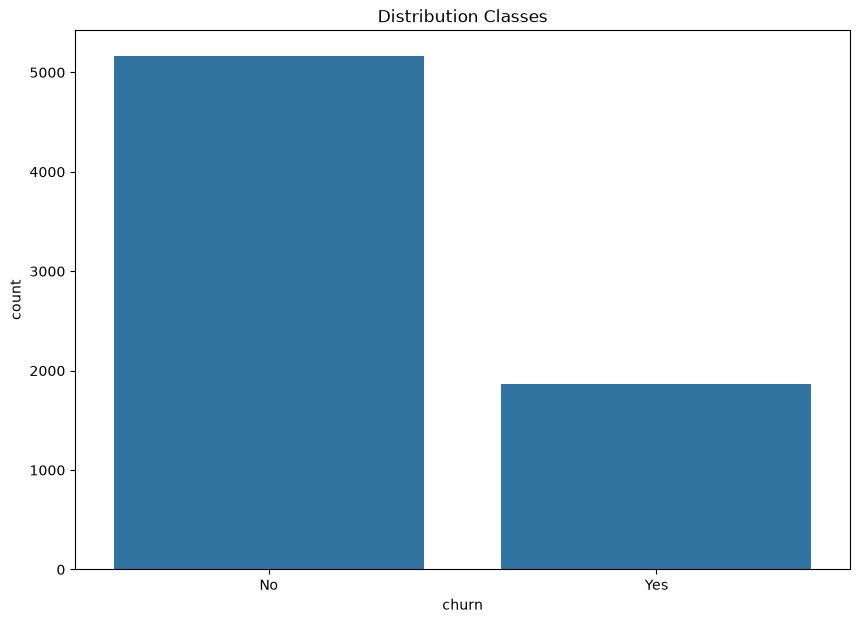

In [17]:
# visualizing the distribution of the target

plt.figure(figsize=(10,7))
sns.countplot(customer_data,x='churn')
plt.title('Distribution Classes')
plt.xlabel('churn')
plt.ylabel('count')
plt.show()

## step 6: split into train and test, splitting features(predictors) and the target
__splitting the target from the feature__

In [20]:
X = customer_data.drop(columns = ['customerid','churn'])
y = customer_data['churn']

**splitting into train and test**

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42, stratify=y)

In [23]:
print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


## step 7 : Preporocessing(encoding, scaling)

__encoding the target column__

In [24]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

### building preprocessing pipeline
__Building a pipeline for the categorical columns__

In [25]:
categorical_columns = X_train.select_dtypes(include = ['str','object']).columns.tolist()
categorical_columns.append('seniorcitizen')
print(categorical_columns)

['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'seniorcitizen']


In [26]:
cat_pipeline = Pipeline([('encoder',OneHotEncoder(handle_unknown = 'ignore'))])

__building a numerical pipeline__

In [27]:
numerical_columns = X_train.select_dtypes(include= ['int','float']).columns.tolist()
numerical_columns.remove('seniorcitizen')
print(numerical_columns)

['tenure', 'monthlycharges', 'totalcharges']


In [28]:
num_pipeline = Pipeline([('scaler',StandardScaler())])

__combining numerical and categorical pipelines__

In [29]:
preprocessor = ColumnTransformer(transformers = 
[('num',num_pipeline,numerical_columns),
('cat',cat_pipeline,categorical_columns)])

In [30]:
pipelines = {'LogisticRegression': Pipeline([('preprocessor',preprocessor),
('model', LogisticRegression(max_iter = 1000))]),
'KNeighborsClassifier': Pipeline([('preprocessor',preprocessor),
('model', KNeighborsClassifier(n_neighbors=7,metric= 'euclidean'))]),
'RandomForestClassifier': Pipeline([('preprocessor',preprocessor),
('model', RandomForestClassifier(n_estimators = 1000, max_depth = 10))])}

for model, pipeline in pipelines.items():
    print('-'*40,model,'-'*40)
    pipeline.fit(X_train,y_train_encoded)
    y_pred = pipeline.predict(X_test)
    print('classificationreport \n',classification_report(y_test_encoded, y_pred, target_names = le.classes_))   


---------------------------------------- LogisticRegression ----------------------------------------
classificationreport 
               precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

---------------------------------------- KNeighborsClassifier ----------------------------------------
classificationreport 
               precision    recall  f1-score   support

          No       0.84      0.83      0.84      1033
         Yes       0.55      0.57      0.56       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.76      0.76      1407

---------------------------------------- RandomForestClassifier --------------------------------

**select the best performing model**

In [31]:
full_pipeline =  Pipeline([('preprocessor',preprocessor),
('model', LogisticRegression(max_iter = 1000))])

**training the final model**

In [32]:
full_pipeline.fit(X_train,y_train_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','seniorcitizen','partner',...,'paymentmethod','monthlycharges', 'totalcharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

## step 8 : saving the final pipeline/model and encoders for the target

In [33]:
# saving the target encorders
joblib.dump(le, '../models/target_labels.joblib')

# saving ml pipeline 
joblib.dump(full_pipeline,'../models/ml_pipeline.joblib')

['../models/ml_pipeline.joblib']